In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import pandas as pd
import os
import glob
import math

#Pending 006 , 007, 008
all_images = glob.glob(r'XY_clean\Batch(91-99)\*.jpg')
batch_size = 10
num_batches = math.ceil(len(all_images) / batch_size)
csv_filename = "Global_Results.csv"
print("Total de imágenes encontradas:", len(all_images))
print(all_images)



Total de imágenes encontradas: 4
['XY_clean\\Batch(91-99)\\xy091.jpg', 'XY_clean\\Batch(91-99)\\xy092.jpg', 'XY_clean\\Batch(91-99)\\xy093.jpg', 'XY_clean\\Batch(91-99)\\xy094.jpg']


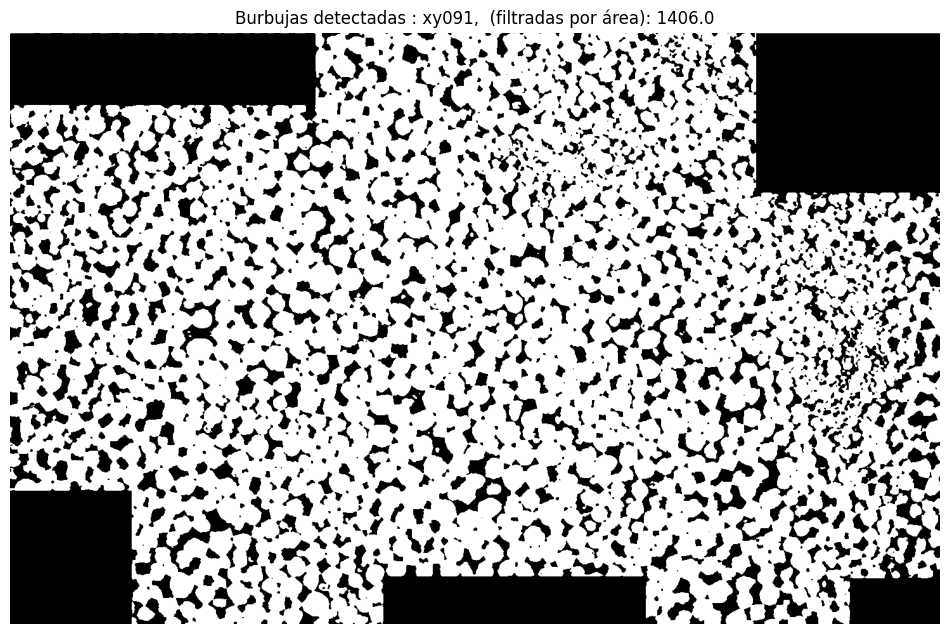

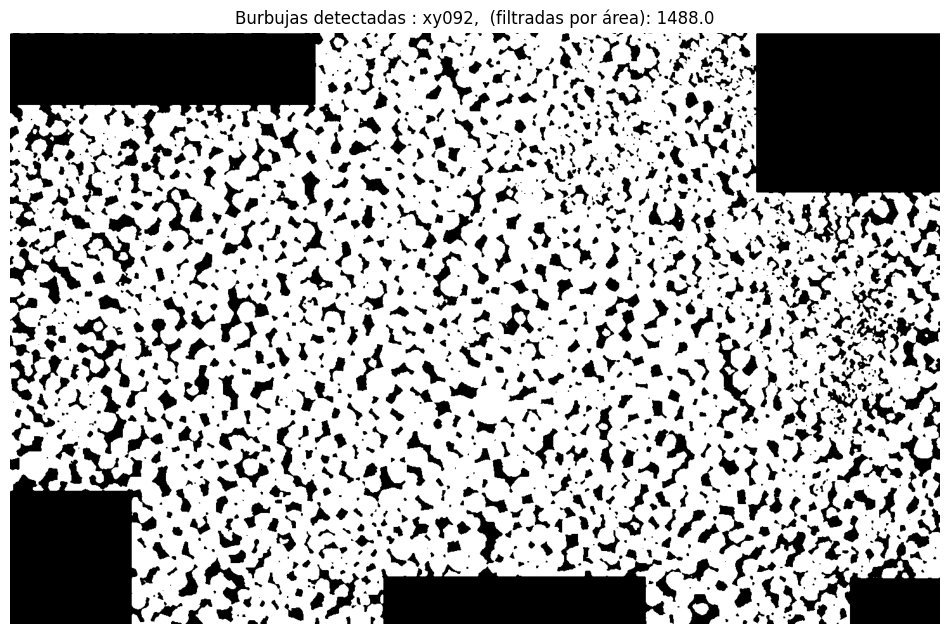

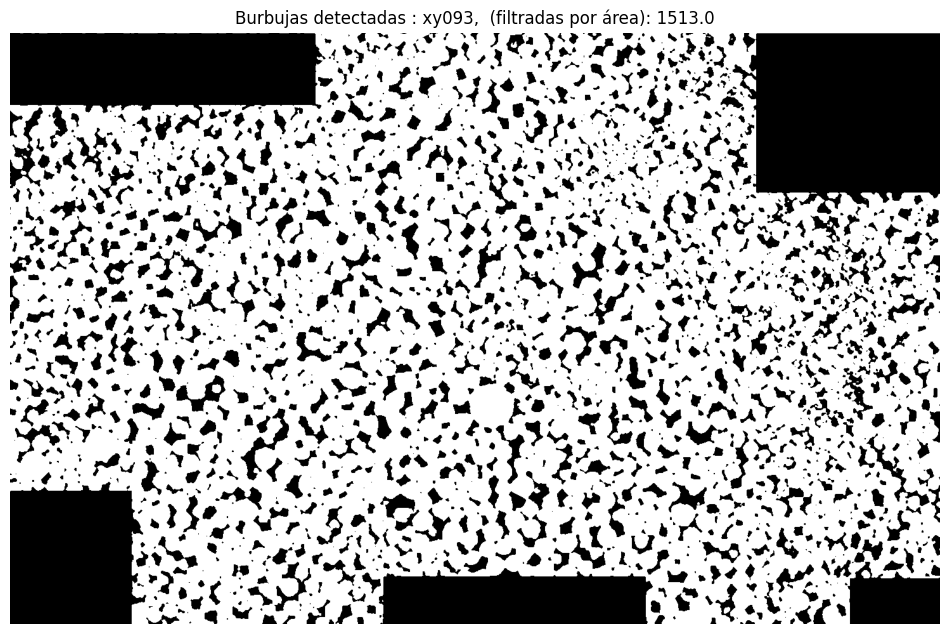

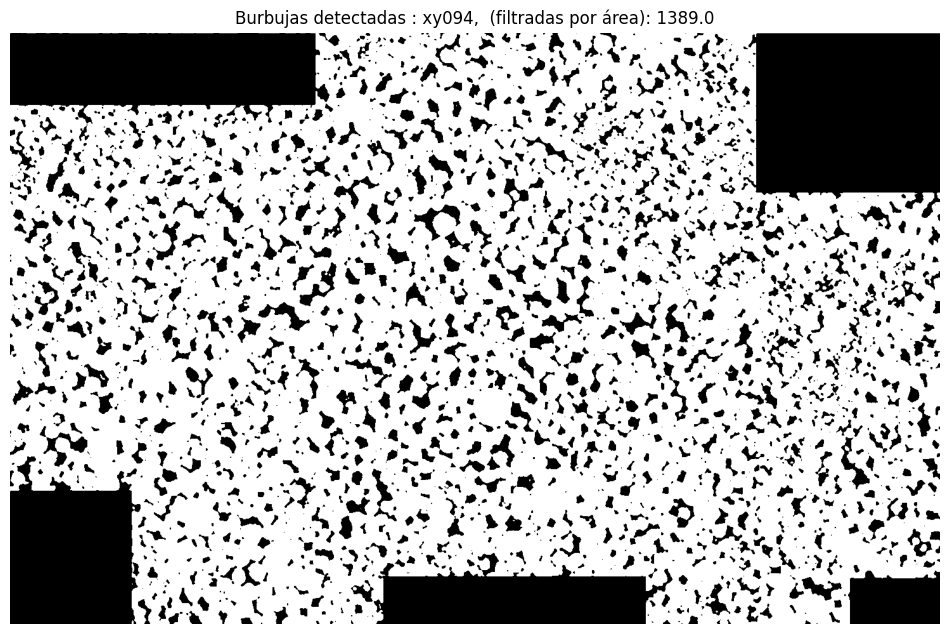

  Imagen  Scene_coordinate_system  Area_px  Area_mm2  Perimetro_px  \
0  xy091                      0.0      394  0.003707     89.355338   
1  xy091                      0.0     1270  0.011950    181.639609   
2  xy091                      0.0      238  0.002239     62.526911   
3  xy091                      0.0      277  0.002606     75.597979   
4  xy091                      0.0      420  0.003952     76.911687   

   Perimetro_mm  Diametro_px  Diametro_mm  Escala_mm_por_px  
0      0.274096    22.397687     0.068705          0.003067  
1      0.557177    40.212115     0.123350          0.003067  
2      0.191800    17.407786     0.053398          0.003067  
3      0.231896    18.779972     0.057607          0.003067  
4      0.235925    23.124892     0.070935          0.003067  
Se detectaron 5796 burbujas en este lote.


In [2]:
for i in range(num_batches):
    batch_images = all_images[i*batch_size : (i+1)*batch_size]
    batch_data = []

    for image_path in batch_images:
        # Definir umbrales
        max_area_threshold = 8000
        min_area_threshold = 0

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image_name = os.path.splitext(os.path.basename(image_path))[0]

        # 1. Suavizar la imagen
        blur = cv2.GaussianBlur(image, (5,5), 0) #Smooth for 5,5 >90

        # 2. Umbral Otsu
        _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        binary = cv2.bitwise_not(binary)

        # 3. Limpiar por morfologia 
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
        binary_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=5)

        # 4. Trasnformada de dist
        dist_transform = cv2.distanceTransform(binary_opened, cv2.DIST_L2, 5)

        # 5. Picos locales
        coordinates = peak_local_max(dist_transform, min_distance=10)
        local_max = np.zeros(dist_transform.shape, dtype=bool)
        local_max[tuple(coordinates.T)] = True

        # Labels bubbles
        markers, _ = ndimage.label(local_max)

        # 6. Bubbles indentificacion
        labels = watershed(-dist_transform, markers, mask=binary_opened)

        # 7. Resultado
        num_labels = labels.max()
        np.random.seed(42)
        colors = np.random.randint(0, 255, (num_labels+1, 3), dtype=np.uint8)

        colored_result = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)
        valid_count = 0.
        
        scene_coordinate_system = 0.00
        width_pixels = image.shape[1]
        escala_mm_px = 4.5 / width_pixels
        #Proceso Para indentificar filtro 
        for lbl in range(1, num_labels+1):
            mask = (labels == lbl).astype(np.uint8)
            area_px = cv2.countNonZero(mask)

            if min_area_threshold <= area_px <= max_area_threshold:
                
                contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if len(contours) > 0:
                    perimeter_px = cv2.arcLength(contours[0], True)
                else:
                    perimeter_px = 0.0

                diametro_px = math.sqrt((4 * area_px) / math.pi)
                area_mm2 = area_px * (escala_mm_px**2)
                perimetro_mm = perimeter_px * escala_mm_px
                diametro_mm = diametro_px * escala_mm_px

                
                colored_result[labels == lbl] = colors[lbl]

                
                batch_data.append({
                    'Imagen': image_name,
                    'Scene_coordinate_system': scene_coordinate_system,
                    'Area_px': area_px,
                    'Area_mm2': area_mm2,
                    'Perimetro_px': perimeter_px,
                    'Perimetro_mm': perimetro_mm,
                    'Diametro_px': diametro_px,
                    'Diametro_mm': diametro_mm,
                    'Escala_mm_por_px': escala_mm_px
                })

                valid_count += 1

        
        plt.figure(figsize=(12,12))
        plt.imshow(cv2.cvtColor(binary, cv2.COLOR_BGR2RGB))
        plt.title(f"Burbujas detectadas : {image_name},  (filtradas por área): {valid_count}")
        plt.axis('off')
        plt.show()

    df_batch = pd.DataFrame(batch_data)
    print(df_batch.head())
    print(f"Se detectaron {len(df_batch)} burbujas en este lote.")


In [ ]:
respuesta = input("¿Los resultados se ven correctos? (s/n): ")
if respuesta.lower() == 's':
        #CSV global
        if not os.path.exists(csv_filename):
            df_batch.to_csv(csv_filename, index=False)
        else:
            df_batch.to_csv(csv_filename, mode='a', header=False, index=False)
        print("Resultados añadidos al CSV global.")
else:
        print("Lote descartado. Ajusta parámetros y vuelve a procesar este lote.")

Resultados añadidos al CSV global.
